# Resonator TOF bring-up

First real-resonator measurement notebook.

Plan:

1. AWG emits a 50 MHz IF readout pulse.
2. SGS100A is the microwave LO.
3. The resonator drive is treated as upper-sideband:
   `f_resonator_drive = f_sgs + fc`.
4. Start at the design frequency, 5.9 GHz, so `f_sgs = 5.85 GHz`.
5. Run TOF first, then use SGS100A to sweep around the resonator.

Run cells in order. Keep the initial `READOUT_GAIN` conservative and increase
only after checking the ATS voltage range.

In [11]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from QAWG import AWGAlazar, ExperimentProgram, LinearSweep, MHz, ns, us
from QAWG import calculate_window
from QAWG.instrument import RohdeSchwarzSGS100A

## Hardware and frequency parameters

In [12]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"
SGS100A_ADDRESS = "192.168.10.90"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9

RESONATOR_DESIGN_HZ = 5.9e9
FC_HZ = 50 * MHz
SIDEBAND = +1  # +1: RF = SGS + fc, -1: RF = SGS - fc
SGS_CENTER_HZ = RESONATOR_DESIGN_HZ - SIDEBAND * FC_HZ

SGS_POWER_DBM = -20.0
SGS_SETTLE_S = 0.05

# Physical wiring. Adjust these before running if the bench wiring differs.
AWG_CH = 1
MARKER_CH = 1
ADC_CHANNEL = "CHB"

CHANNEL_AMPLITUDE_VPP = 0.5
READOUT_GAIN = 0.02
READOUT_LENGTH = 600 * ns
EDGE_SIGMA = 20 * ns
MARKER_PADDING = 500 * ns
TRIGGER_DELAY = 500 * ns
INTEGRATE_TIME = 1.0 * us
ACQUIRE_LENGTH = 1.5 * us
FINAL_DELAY = 1.0 * us

TOF_N_AVERAGE = 1000
TRIGGER_LEVEL = 140
ALAZAR_TIMEOUT_MS = 60_000

# Used by calculate_window(). Increase this to capture more baseline before
# the resonator response arrives.
WINDOW_TRIGGER_LEAD = 120 * ns
WINDOW_INTEGRATION_GUARD = 20 * ns

print(f"fc = {FC_HZ / MHz:.3f} MHz")
print(f"Design resonator = {RESONATOR_DESIGN_HZ / 1e9:.9f} GHz")
print(f"Initial SGS100A = {SGS_CENTER_HZ / 1e9:.9f} GHz")
print(f"AWG channel full scale = {CHANNEL_AMPLITUDE_VPP:.3f} V")
print(f"Readout gain = {READOUT_GAIN:.6f}")
print(f"Readout waveform peak = {READOUT_GAIN * CHANNEL_AMPLITUDE_VPP * 1e3:.6f} mV")
print(
    "Initial microwave drive = "
    f"{(SGS_CENTER_HZ + SIDEBAND * FC_HZ) / 1e9:.9f} GHz"
)

fc = 50.000 MHz
Design resonator = 5.900000000 GHz
Initial SGS100A = 5.850000000 GHz
AWG channel full scale = 0.500 V
Readout gain = 0.020000
Readout waveform peak = 10.000000 mV
Initial microwave drive = 5.900000000 GHz


## Connect and configure SGS100A

In [13]:
sgs = RohdeSchwarzSGS100A(SGS100A_ADDRESS)
sgs.frequency = SGS_CENTER_HZ
sgs.power = SGS_POWER_DBM
sgs.IQ_state = "on"
sgs.pulsemod_state = "off"
sgs.configure_lo_output(True, mode="LO")
sgs.on()

print("SGS100A:", sgs.idn())
print(f"Frequency: {sgs.frequency / 1e9:.9f} GHz")
print(f"Power: {sgs.power:.3f} dBm")
print("Main RF output:", sgs.status)
print("External IQ modulation:", sgs.IQ_state)
print("Pulse modulation:", sgs.pulsemod_state)
print("Rear REF/LO output:", sgs.ref_lo_output)
print("Instrument error:", sgs.check_error())

Connected to: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
SGS100A: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
Frequency: 5.850000000 GHz
Power: -20.000 dBm
Main RF output: on
External IQ modulation: on
Pulse modulation: off
Rear REF/LO output: LO
Instrument Status: 0,"No error"
Instrument error: 0,"No error"


## TOF program

In [14]:
class ResonatorTOFProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["frequency"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )
        self.add_pulse(
            "tof_readout",
            gen="readout",
            style="gaussian_square",
            length=cfg["readout_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["frequency"],
            gain=cfg["readout_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("tof_readout", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


tof_cfg = {
    "awg_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "frequency": FC_HZ,
    "readout_length": READOUT_LENGTH,
    "marker_padding": MARKER_PADDING,
    "edge_sigma": EDGE_SIGMA,
    "readout_gain": READOUT_GAIN,
    "acquire_length": ACQUIRE_LENGTH,
    "trigger_delay": TRIGGER_DELAY,
    "integrate_time": INTEGRATE_TIME,
}

## Connect AWG + ATS and compile TOF

In [15]:
experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    acquire_window_s=ACQUIRE_LENGTH,
    trigger_slope="rising",
    trigger_level=TRIGGER_LEVEL,
    timeout_ms=ALAZAR_TIMEOUT_MS,
    use_external_10mhz_reference=True,
)

tof_program = ResonatorTOFProgram(tof_cfg, final_delay_s=FINAL_DELAY)
tof_program.REMOVE_DC_OFFSET = True
tof_compiled = tof_program.compile(hardware=experiment)

if AWG_CH == MARKER_CH:
    print(f"Analog readout and marker share AWG CH{AWG_CH}.")

marker_samples = np.flatnonzero(tof_compiled.marker_waveforms[0])
marker_start_ns = marker_samples[0] / experiment.awg_sample_rate_hz / ns
marker_stop_ns = (marker_samples[-1] + 1) / experiment.awg_sample_rate_hz / ns
readout_start_ns, readout_stop_ns = tof_compiled.readout_windows_s[0] / ns

print("AWG:", experiment.awg.identify())
print("Sequence steps:", tof_compiled.number_of_sequence_steps)
print("AWG step duration:", tof_compiled.step_duration_s / us, "us")
print(f"Readout IF: {FC_HZ / MHz:.3f} MHz")
print(f"Readout window: {readout_start_ns:.3f} to {readout_stop_ns:.3f} ns")
print(f"Marker window: {marker_start_ns:.3f} to {marker_stop_ns:.3f} ns")
print("ATS post-trigger delay:", TRIGGER_DELAY / ns, "ns")
print("ATS acquire window:", experiment.acquire_window_cycles, "samples")

Analog readout and marker share AWG CH1.
AWG: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
Sequence steps: 1
AWG step duration: 3.0 us
Readout IF: 50.000 MHz
Readout window: 500.000 to 1100.000 ns
Marker window: 0.000 to 1600.000 ns
ATS post-trigger delay: 500.00000000000006 ns
ATS acquire window: 1536 samples


## Acquire TOF trace

In [16]:
tof_result = tof_compiled.acquire(
    n_average=TOF_N_AVERAGE,
    filter_type="boxcar",
)

raw_time_ns = tof_result.raw_time_s / ns
iq_time_ns = tof_result.iq_time_s / ns
raw_avg_mv = tof_result.trace_average("ro")[0] * 1e3
iq_avg = tof_result.iq_trace_average("ro")[0]
iq_abs_mv = np.abs(iq_avg) * 1e3
iq_point = tof_result.iq_average("ro")[0]

print("Raw records (shot, step, time):", tof_result.raw.shape)
print("IQ traces (shot, step, time):", tof_result.iq_traces.shape)
print(f"Integrated IQ: I={iq_point.real * 1e3:.6f} mV, Q={iq_point.imag * 1e3:.6f} mV")
print("SGS error:", sgs.check_error())
print("AWG error:", experiment.awg.error())
for key, value in experiment.capture_diagnostics().items():
    print(f"{key}: {value}")

Raw records (shot, step, time): (1000, 1, 1536)
IQ traces (shot, step, time): (1000, 1, 1000)
Integrated IQ: I=-0.000942 mV, Q=-0.000901 mV
Instrument Status: 0,"No error"
SGS error: 0,"No error"
AWG error: 0,"No error"
adc_channel: CHB
adc_bits: 12
adc_lsb_mv: 0.1953125
raw_code_min: 32560
raw_code_max: 32912
mean_offset_mv: -0.40049476623535135
average_peak_to_peak_mv: 0.3068359374999984
shot_noise_std_mv: 0.42493473015180944


## Plot raw and demodulated TOF

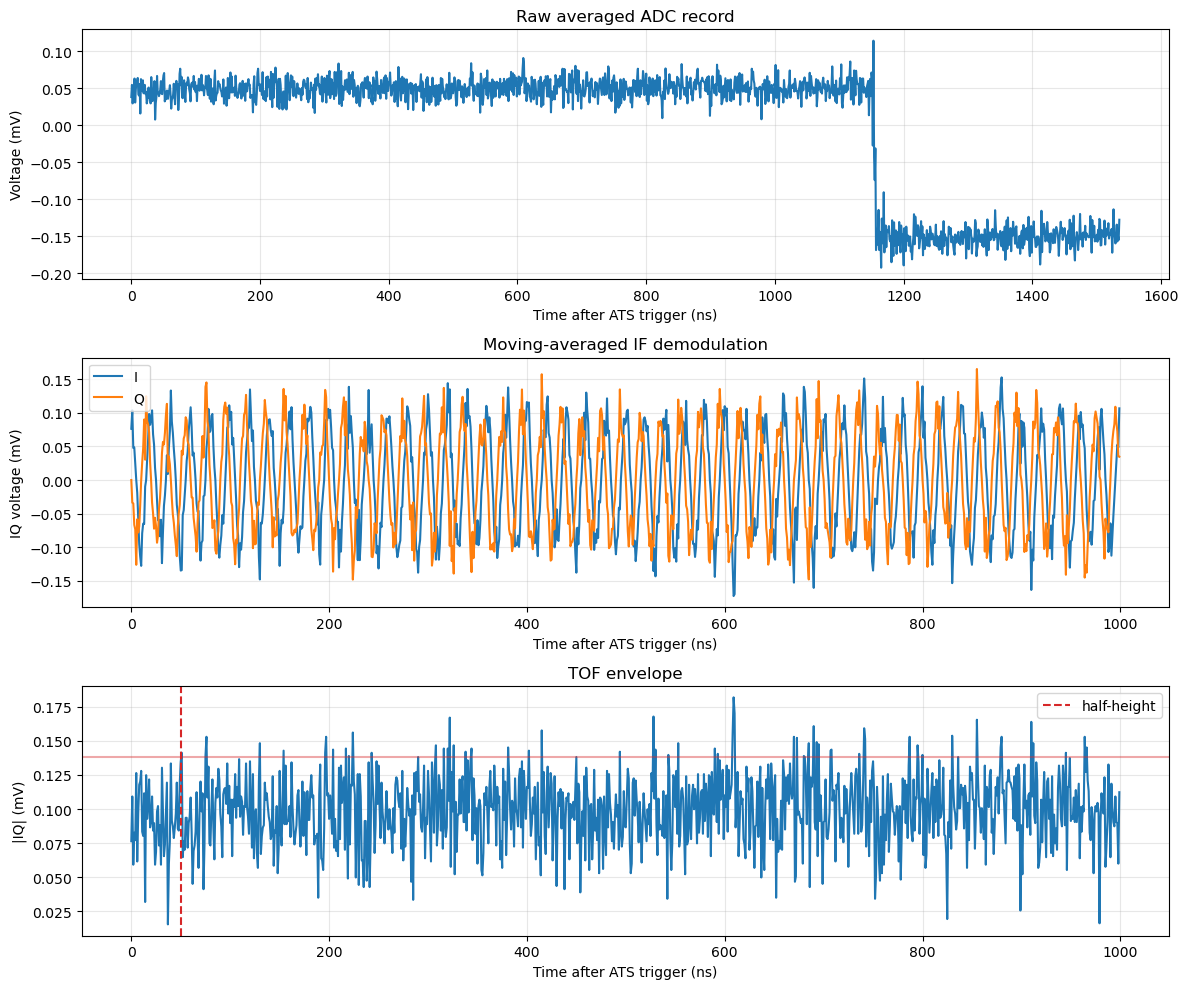

Estimated arrival from ATS trigger: 50.500 ns
Envelope baseline: 0.094349 mV
Envelope peak: 0.181849 mV


In [17]:
def estimate_arrival_ns(time_ns, magnitude_mv, baseline_fraction=0.15):
    baseline_stop = max(5, int(round(baseline_fraction * magnitude_mv.size)))
    baseline = np.median(magnitude_mv[:baseline_stop])
    peak = np.max(magnitude_mv)
    height = peak - baseline
    if height <= 0:
        return np.nan, baseline, peak, np.nan
    threshold = baseline + 0.5 * height
    above = np.flatnonzero(magnitude_mv >= threshold)
    if above.size == 0 or above[0] == 0:
        return np.nan, baseline, peak, threshold
    right = above[0]
    left = right - 1
    y0, y1 = magnitude_mv[left], magnitude_mv[right]
    fraction = 0.0 if y1 == y0 else (threshold - y0) / (y1 - y0)
    arrival = time_ns[left] + fraction * (time_ns[right] - time_ns[left])
    return arrival, baseline, peak, threshold


arrival_ns, baseline_mv, peak_mv, threshold_mv = estimate_arrival_ns(
    iq_time_ns,
    iq_abs_mv,
)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
axes[0].plot(raw_time_ns, raw_avg_mv)
axes[0].set_title("Raw averaged ADC record")
axes[0].set_xlabel("Time after ATS trigger (ns)")
axes[0].set_ylabel("Voltage (mV)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(iq_time_ns, iq_avg.real * 1e3, label="I")
axes[1].plot(iq_time_ns, iq_avg.imag * 1e3, label="Q")
axes[1].set_title("Moving-averaged IF demodulation")
axes[1].set_xlabel("Time after ATS trigger (ns)")
axes[1].set_ylabel("IQ voltage (mV)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(iq_time_ns, iq_abs_mv)
if np.isfinite(arrival_ns):
    axes[2].axvline(arrival_ns, color="tab:red", linestyle="--", label="half-height")
    axes[2].axhline(threshold_mv, color="tab:red", alpha=0.4)
axes[2].set_title("TOF envelope")
axes[2].set_xlabel("Time after ATS trigger (ns)")
axes[2].set_ylabel("|IQ| (mV)")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Estimated arrival from ATS trigger: {arrival_ns:.3f} ns")
print(f"Envelope baseline: {baseline_mv:.6f} mV")
print(f"Envelope peak: {peak_mv:.6f} mV")

## Calculate suggested trigger and integration window

Initial post-trigger delay: 500.000 ns
Measured readout arrival: 0.000 ns
Compiled readout duration: 600.000 ns
Suggested post-trigger delay: 380.000 ns
Suggested integration window: 0.000 to 740.000 ns
DC offset removal: True
Use these after checking the plotted window:
TRIGGER_DELAY = 380.000 ns
INTEGRATE_TIME = 740.000 ns


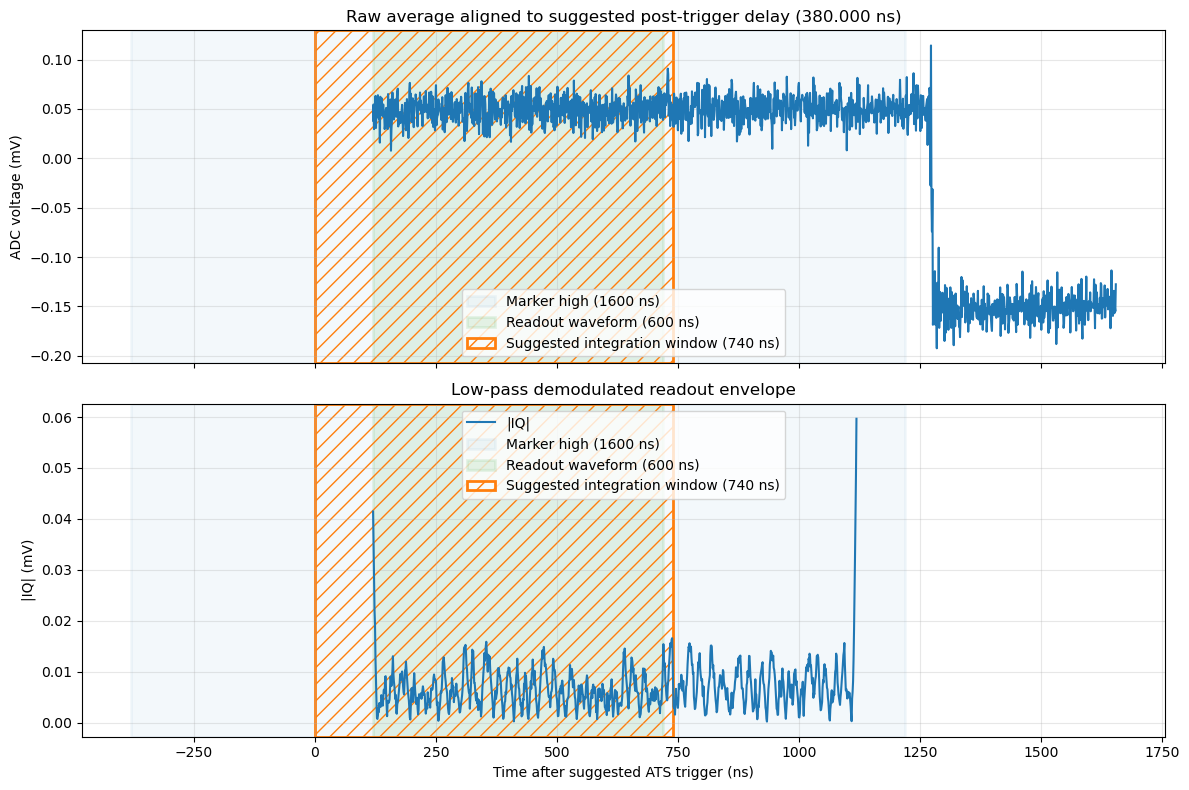

In [18]:
window = calculate_window(
    tof_result,
    trigger_lead_s=WINDOW_TRIGGER_LEAD,
    integration_guard_s=WINDOW_INTEGRATION_GUARD,
    plot=True,
    report=True,
)

SUGGESTED_TRIGGER_DELAY = window.suggested_trigger_delay_s
SUGGESTED_INTEGRATE_TIME = window.integration_stop_s - window.integration_start_s

print("Use these after checking the plotted window:")
print(f"TRIGGER_DELAY = {SUGGESTED_TRIGGER_DELAY / ns:.3f} ns")
print(f"INTEGRATE_TIME = {SUGGESTED_INTEGRATE_TIME / ns:.3f} ns")

## Optional: SGS100A frequency sweep around 5.9 GHz

In [19]:
# Sweep target microwave drive frequencies. SGS100A is adjusted by subtracting fc.
DRIVE_SPAN_HZ = 20 * MHz
DRIVE_POINTS = 41
SWEEP_N_AVERAGE = 300

drive_frequency_hz = np.linspace(
    RESONATOR_DESIGN_HZ - DRIVE_SPAN_HZ / 2,
    RESONATOR_DESIGN_HZ + DRIVE_SPAN_HZ / 2,
    DRIVE_POINTS,
)
sgs_frequency_hz = drive_frequency_hz - SIDEBAND * FC_HZ

sweep_iq = []
sweep_peak_mv = []
sweep_arrival_ns = []

for index, (drive_hz, sgs_hz) in enumerate(zip(drive_frequency_hz, sgs_frequency_hz)):
    sgs.frequency = float(sgs_hz)
    time.sleep(SGS_SETTLE_S)
    result = tof_compiled.acquire(
        n_average=SWEEP_N_AVERAGE,
        filter_type="boxcar",
    )
    avg_iq = result.iq_trace_average("ro")[0]
    mag_mv = np.abs(avg_iq) * 1e3
    point = result.iq_average("ro")[0]
    arrival, _, peak, _ = estimate_arrival_ns(result.iq_time_s / ns, mag_mv)

    sweep_iq.append(point)
    sweep_peak_mv.append(peak)
    sweep_arrival_ns.append(arrival)
    print(
        f"{index + 1:02d}/{DRIVE_POINTS}: "
        f"drive={drive_hz / 1e9:.9f} GHz, "
        f"sgs={sgs_hz / 1e9:.9f} GHz, "
        f"|IQ|={abs(point) * 1e3:.6f} mV, "
        f"peak={peak:.6f} mV, "
        f"arrival={arrival:.3f} ns"
    )

sweep_iq = np.asarray(sweep_iq)
sweep_peak_mv = np.asarray(sweep_peak_mv)
sweep_arrival_ns = np.asarray(sweep_arrival_ns)

01/41: drive=5.890000000 GHz, sgs=5.840000000 GHz, |IQ|=0.000888 mV, peak=0.239126 mV, arrival=4.788 ns
02/41: drive=5.890500000 GHz, sgs=5.840500000 GHz, |IQ|=0.000116 mV, peak=0.256747 mV, arrival=60.841 ns
03/41: drive=5.891000000 GHz, sgs=5.841000000 GHz, |IQ|=0.000901 mV, peak=0.238011 mV, arrival=13.600 ns
04/41: drive=5.891500000 GHz, sgs=5.841500000 GHz, |IQ|=0.001073 mV, peak=0.276195 mV, arrival=30.700 ns
05/41: drive=5.892000000 GHz, sgs=5.842000000 GHz, |IQ|=0.000828 mV, peak=0.231695 mV, arrival=13.877 ns
06/41: drive=5.892500000 GHz, sgs=5.842500000 GHz, |IQ|=0.000743 mV, peak=0.255910 mV, arrival=58.907 ns
07/41: drive=5.893000000 GHz, sgs=5.843000000 GHz, |IQ|=0.000966 mV, peak=0.256944 mV, arrival=19.824 ns
08/41: drive=5.893500000 GHz, sgs=5.843500000 GHz, |IQ|=0.000617 mV, peak=0.243067 mV, arrival=9.926 ns
09/41: drive=5.894000000 GHz, sgs=5.844000000 GHz, |IQ|=0.000924 mV, peak=0.274301 mV, arrival=16.786 ns
10/41: drive=5.894500000 GHz, sgs=5.844500000 GHz, |IQ|=0

KeyboardInterrupt: 

## Plot frequency sweep

In [ ]:
drive_detuning_mhz = (drive_frequency_hz - RESONATOR_DESIGN_HZ) / MHz

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(drive_detuning_mhz, np.abs(sweep_iq) * 1e3, "o-")
axes[0, 0].set_xlabel("Drive detuning from design (MHz)")
axes[0, 0].set_ylabel("Integrated |IQ| (mV)")
axes[0, 0].set_title("Integrated response")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(drive_detuning_mhz, sweep_peak_mv, "o-")
axes[0, 1].set_xlabel("Drive detuning from design (MHz)")
axes[0, 1].set_ylabel("Envelope peak (mV)")
axes[0, 1].set_title("TOF peak response")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(sweep_iq.real * 1e3, sweep_iq.imag * 1e3, "o-")
axes[1, 0].set_xlabel("I (mV)")
axes[1, 0].set_ylabel("Q (mV)")
axes[1, 0].set_title("IQ circle / response trajectory")
axes[1, 0].axis("equal")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(drive_detuning_mhz, sweep_arrival_ns, "o-")
axes[1, 1].set_xlabel("Drive detuning from design (MHz)")
axes[1, 1].set_ylabel("Estimated arrival (ns)")
axes[1, 1].set_title("TOF estimate versus frequency")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Optional: fixed SGS100A, AWG fc sweep from 50 to 150 MHz

In [ ]:
# Keep SGS100A fixed at 5.9 GHz - 50 MHz = 5.85 GHz.
# The microwave drive follows RF = SGS + fc, so this sweeps 5.90 to 6.00 GHz.
FIXED_SGS_HZ = RESONATOR_DESIGN_HZ - 50 * MHz
AWG_FC_START_HZ = 50 * MHz
AWG_FC_STOP_HZ = 150 * MHz
AWG_FC_POINTS = 51
AWG_FC_SWEEP_N_AVERAGE = 300

USE_CALCULATED_WINDOW = True

awg_fc_hz = np.linspace(
    AWG_FC_START_HZ,
    AWG_FC_STOP_HZ,
    AWG_FC_POINTS,
)
awg_drive_hz = FIXED_SGS_HZ + SIDEBAND * awg_fc_hz

sgs.frequency = FIXED_SGS_HZ
time.sleep(SGS_SETTLE_S)
print(f"Fixed SGS100A frequency: {sgs.frequency / 1e9:.9f} GHz")

awg_fc_iq = []
awg_fc_peak_mv = []
awg_fc_arrival_ns = []
awg_fc_windows = []

for index, (fc_hz, drive_hz) in enumerate(zip(awg_fc_hz, awg_drive_hz)):
    sweep_cfg = {
        **tof_cfg,
        "frequency": float(fc_hz),
    }
    if USE_CALCULATED_WINDOW and "window" in globals():
        sweep_cfg["trigger_delay"] = float(window.suggested_trigger_delay_s)
        sweep_cfg["integrate_time"] = float(
            window.integration_stop_s - window.integration_start_s
        )

    program = ResonatorTOFProgram(
        sweep_cfg,
        name=f"awg_fc_{fc_hz / MHz:07.3f}_MHz",
        final_delay_s=FINAL_DELAY,
    )
    program.REMOVE_DC_OFFSET = True
    compiled = program.compile(hardware=experiment)
    result = compiled.acquire(
        n_average=AWG_FC_SWEEP_N_AVERAGE,
        filter_type="boxcar",
    )

    avg_iq = result.iq_trace_average("ro")[0]
    mag_mv = np.abs(avg_iq) * 1e3
    point = result.iq_average("ro")[0]
    arrival, _, peak, _ = estimate_arrival_ns(result.iq_time_s / ns, mag_mv)

    awg_fc_iq.append(point)
    awg_fc_peak_mv.append(peak)
    awg_fc_arrival_ns.append(arrival)
    awg_fc_windows.append(
        (
            result.initial_trigger_delay_s,
            result.readout_windows_s[0, 0],
            result.readout_windows_s[0, 1],
        )
    )
    print(
        f"{index + 1:02d}/{AWG_FC_POINTS}: "
        f"fc={fc_hz / MHz:8.3f} MHz, "
        f"drive={drive_hz / 1e9:.9f} GHz, "
        f"|IQ|={abs(point) * 1e3:.6f} mV, "
        f"peak={peak:.6f} mV, "
        f"arrival={arrival:.3f} ns"
    )

awg_fc_iq = np.asarray(awg_fc_iq)
awg_fc_peak_mv = np.asarray(awg_fc_peak_mv)
awg_fc_arrival_ns = np.asarray(awg_fc_arrival_ns)
awg_fc_windows = np.asarray(awg_fc_windows)

## Plot fixed-SGS AWG-fc sweep

In [ ]:
awg_fc_mhz = awg_fc_hz / MHz
awg_drive_ghz = awg_drive_hz / 1e9

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(awg_fc_mhz, np.abs(awg_fc_iq) * 1e3, "o-")
axes[0, 0].set_xlabel("AWG fc (MHz)")
axes[0, 0].set_ylabel("Integrated |IQ| (mV)")
axes[0, 0].set_title("Integrated response, SGS fixed")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(awg_drive_ghz, awg_fc_peak_mv, "o-")
axes[0, 1].set_xlabel("Microwave drive frequency (GHz)")
axes[0, 1].set_ylabel("Envelope peak (mV)")
axes[0, 1].set_title("TOF peak response")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(awg_fc_iq.real * 1e3, awg_fc_iq.imag * 1e3, "o-")
for fc_mhz, point in zip(awg_fc_mhz[::10], awg_fc_iq[::10]):
    axes[1, 0].annotate(
        f"{fc_mhz:.0f}",
        (point.real * 1e3, point.imag * 1e3),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        fontsize=8,
    )
axes[1, 0].set_xlabel("I (mV)")
axes[1, 0].set_ylabel("Q (mV)")
axes[1, 0].set_title("IQ trajectory")
axes[1, 0].axis("equal")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(awg_fc_mhz, awg_fc_arrival_ns, "o-")
axes[1, 1].set_xlabel("AWG fc (MHz)")
axes[1, 1].set_ylabel("Estimated arrival (ns)")
axes[1, 1].set_title("TOF estimate versus AWG fc")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save data

In [ ]:
output = Path("resonator_tof_capture.npz")
np.savez(
    output,
    resonator_design_hz=RESONATOR_DESIGN_HZ,
    fc_hz=FC_HZ,
    sideband=SIDEBAND,
    sgs_center_hz=SGS_CENTER_HZ,
    raw_time_ns=raw_time_ns,
    raw_avg_mv=raw_avg_mv,
    iq_time_ns=iq_time_ns,
    iq_avg=iq_avg,
    arrival_ns=arrival_ns,
    drive_frequency_hz=globals().get("drive_frequency_hz", np.array([])),
    sgs_frequency_hz=globals().get("sgs_frequency_hz", np.array([])),
    sweep_iq=globals().get("sweep_iq", np.array([])),
    sweep_peak_mv=globals().get("sweep_peak_mv", np.array([])),
    sweep_arrival_ns=globals().get("sweep_arrival_ns", np.array([])),
    fixed_sgs_hz=globals().get("FIXED_SGS_HZ", np.nan),
    awg_fc_hz=globals().get("awg_fc_hz", np.array([])),
    awg_drive_hz=globals().get("awg_drive_hz", np.array([])),
    awg_fc_iq=globals().get("awg_fc_iq", np.array([])),
    awg_fc_peak_mv=globals().get("awg_fc_peak_mv", np.array([])),
    awg_fc_arrival_ns=globals().get("awg_fc_arrival_ns", np.array([])),
    awg_fc_windows=globals().get("awg_fc_windows", np.array([])),
)
print(output.resolve())

## Close hardware

In [ ]:
if "sgs" in globals():
    sgs.off()
    sgs.configure_lo_output(False)
    sgs.close()
    print("SGS100A RF and rear LO outputs disabled")

if "experiment" in globals():
    experiment.close()
    print("AWG VISA session closed")